<a href="https://colab.research.google.com/github/Suhrobjonibodullayev/ML-Learning-Journey/blob/main/05_machine_learning_basics/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [ ]:
from urllib.request import urlretrieve

urlretrieve(medical_charges_url, 'medical.csv')

df = pd.read_csv('medical.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
!pip install jovian --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 1.8 MB/s eta 0:00:00


In [ ]:
import jovian

jovian.commit()

[jovian] Detected Colab notebook...
[jovian] jovian.commit() is no longer required on Google Colab. If you ran this notebook from Jovian, 
then just save this file in Colab using Ctrl+S/Cmd+S and it will be updated on Jovian. 
Also, you can also delete this cell, it's no longer necessary.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

defolt style

In [ ]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

In [ ]:
df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


In [ ]:
fig = px.histogram(df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age',
                   labels={'age': 'Age (Years)'},
                   color_discrete_sequence=['teal'],
                   template='plotly_dark',
                   opacity=0.7,
                   width=800,
                   height=500
                   )
fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig = px.histogram(df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['crimson'],
                   title='Distribution of BMI (Body Mass Index)',
                   labels={'bmi': 'BMI (Body Mass Index)'},
                   template='plotly_dark',
                   opacity=0.7,
                   width=800,
                   height=500
                   )

fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['crimson', 'teal'],
                   title='Annual Medical Charges',
                   labels={'charges': 'Annual Charges (USD)'},
                   template='plotly_dark',
                   opacity=0.7,
                   width=800,
                   height=500
                   )

fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['crimson', 'teal'],
                   title='Annual Medical Charges',
                   labels={'charges': 'Annual Charges (USD)'},
                   template='plotly_dark',
                   opacity=0.7,
                   width=800,
                   height=500
                   )

fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='region',
                   color_discrete_sequence=['crimson', 'teal','blue','yellow'],
                   title='Annual Medical Charges',
                   labels={'charges': 'Annual Charges (USD)'},
                   template='plotly_dark',
                   opacity=0.7,
                   width=800,
                   height=500
                   )

fig.update_layout(bargap=0.1)
fig.show()

In [ ]:
df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [ ]:
px.histogram(df,
             x='smoker',
             color='sex',
             title='Smoker',
             color_discrete_sequence=['crimson', ' #D4AF37'],
             template='plotly_dark',
             opacity=0.7,
             width=800,
             height=500
             )

In [ ]:
px.histogram(df,
             x='children',
             color='sex',
             title='children',
             color_discrete_sequence=['#00674F', 'gold'],
             template='plotly_dark',
             opacity=0.7,
             width=800,
             height=500
             )

In [ ]:
fig = px.scatter(df,
                 x='age',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='Age vs. Charges',
                 color_discrete_sequence=['crimson', 'gold'],
                 template='plotly_dark',
                 width=800,
                 height=500
                 )
fig.update_traces(marker_size=5)
fig.show()

In [ ]:
fig = px.scatter(df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.8,
                 hover_data=['sex'],
                 title='BMI vs. Charges',
                 color_discrete_sequence=['#50C878', 'gold'],
                 template='plotly_dark',
                 width=800,
                 height=500
                 )
fig.update_traces(marker_size=5)
fig.show()

### correlation

In [ ]:
df.charges.corr(df.age)

np.float64(0.2990081933306476)

In [ ]:
df.charges.corr(df.bmi)

np.float64(0.19834096883362895)

In [ ]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = df.smoker.map(smoker_values)
df.charges.corr(smoker_numeric)

np.float64(0.787251430498478)

In [ ]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


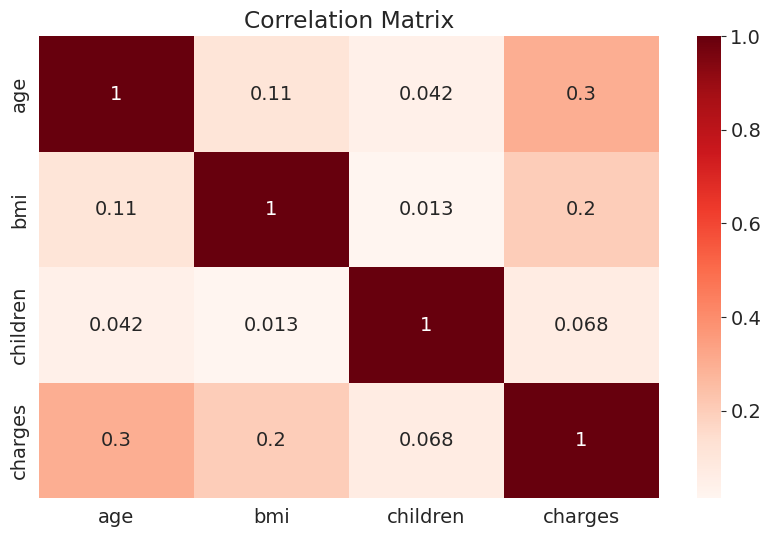

In [ ]:
sns.heatmap(df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Matrix');

### Linear Regression

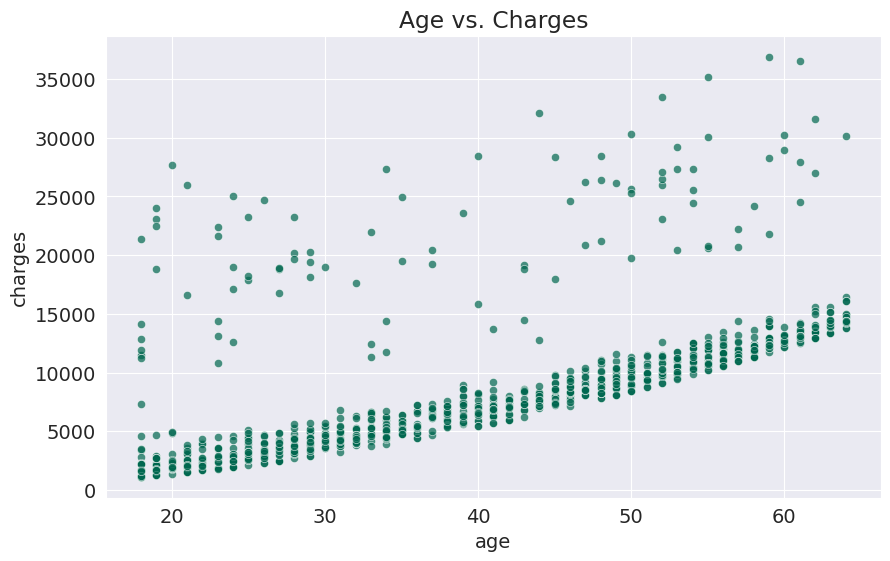

In [ ]:
non_smoker_df = df[df.smoker == 'no']

plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df,
                x='age',
                y='charges',
                alpha=0.7,
                s=35,
                color='#00674F'
                )
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, SGDRegressor

model = LinearRegression()


In [ ]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [ ]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape :', inputs.shape)
print('targes.shape :', targets.shape)

inputs.shape : (1064, 1)
targes.shape : (1064,)


In [ ]:
model.fit(inputs, targets)

LinearRegression()

In [ ]:
predictions = model.predict(inputs)

In [ ]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

rmse(targets, predictions)

np.float64(4662.505766636395)

In [ ]:
# w
model.coef_

array([267.24891283])

In [ ]:
# b
model.intercept_

np.float64(-2091.4205565650864)

RMSE Loss:  4662.505766636395


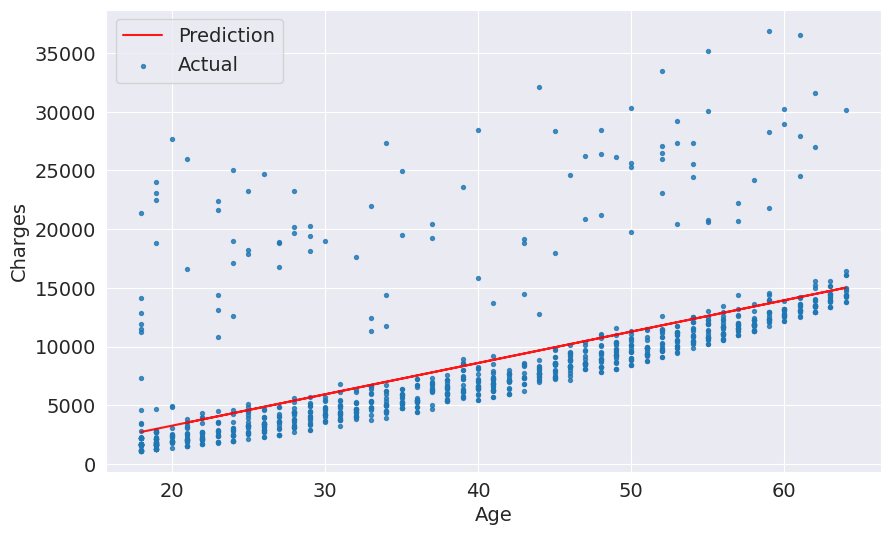

In [ ]:
def estimate_charges(age, w, b):
    return w * age + b

def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

try_parameters(model.coef_, model.intercept_)

In [ ]:
SGDmodel = SGDRegressor(max_iter=1000)

In [ ]:
SGDmodel.fit(inputs, targets)

SGDRegressor()

In [ ]:
predictions = SGDmodel.predict(inputs)

RMSE Loss:  4819.121338902382


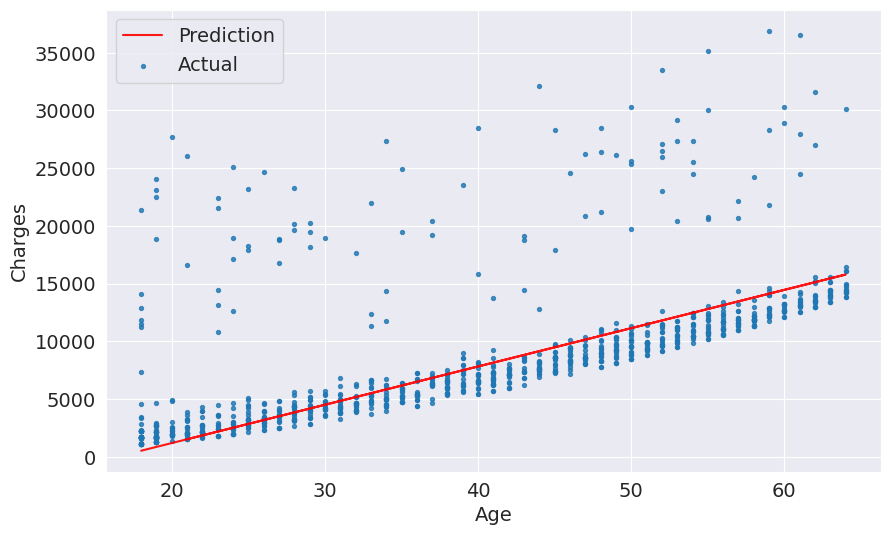

In [ ]:
try_parameters(SGDmodel.coef_, SGDmodel.intercept_)

In [ ]:
# Create inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.3128354612945


In [ ]:
fig = px.scatter(non_smoker_df,
                 x='bmi',
                 y='charges',
                 title='BMI vs. Charges',
                 color_discrete_sequence=['#50C878'],
                 template='plotly_dark',
                 width=800,
                 height=500
                 )
fig.update_traces(marker_size=5)
fig.show()

In [ ]:
fig = px.scatter_3d(non_smoker_df,
                    x='age',
                    y='bmi',
                    z='charges',
                    title='Age, BMI, and Charges',
                    template='plotly_dark',
                    width=800,
                    height=500
                    )
fig.update_traces(marker_size=3, marker_opacity=0.5)
fig.show()

In [ ]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [ ]:
fig = px.strip(non_smoker_df,
               x='children',
               y='charges',
               title= "Children vs. Charges",
               template='plotly_dark',
               color_discrete_sequence=['#50C878'],
               width=800,
               height=500,
               )
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

In [ ]:
# Create inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4608.470405038247


In [ ]:
# Create inputs and targets
inputs, targets = df[['age', 'bmi', 'children']], df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


/tmp/ipykernel_1058/2384575093.py:1: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




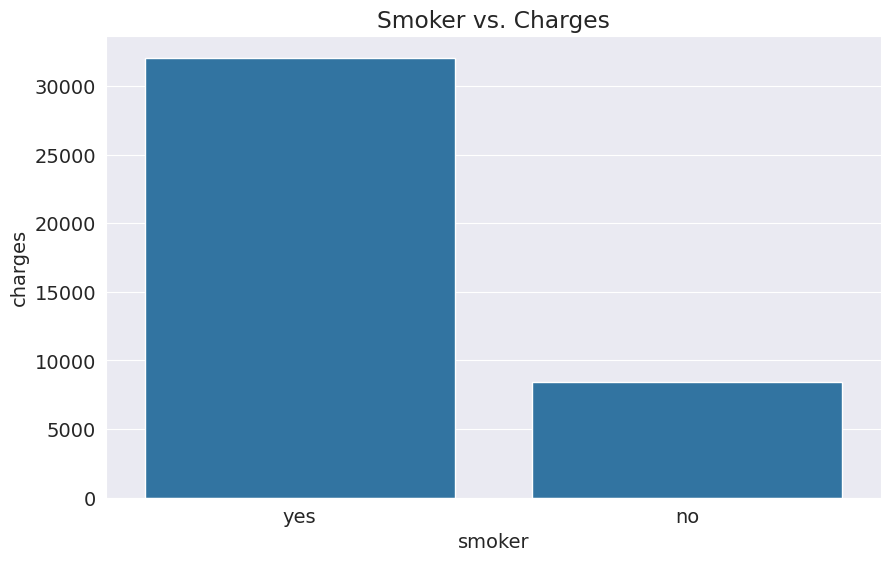

In [ ]:
sns.barplot(data=df,
            x='smoker',
            y='charges',
            ci=None,
            )
plt.title('Smoker vs. Charges')
plt.show()

Encoding

In [ ]:
smoker_codes = {'no': 0, 'yes': 1}
df['smoker'] = df.smoker.map(smoker_codes)

sex_codes = {'female': 0, 'male': 1}
df['sex'] = df.sex.map(sex_codes)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [ ]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [ ]:
one_hot = enc.transform(df[['region']]).toarray()

df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot

df = df.drop(columns=['region'])
df.head()

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0.0,0.0,0.0,1.0
1,18,1,33.770,1,0,1725.55230,0.0,0.0,1.0,0.0
2,28,1,33.000,3,0,4449.46200,0.0,0.0,1.0,0.0
3,33,1,22.705,0,0,21984.47061,0.0,1.0,0.0,0.0
4,32,1,28.880,0,0,3866.85520,0.0,1.0,0.0,0.0


In [ ]:
# Create inputs and targets
input_cols = ['age', 'bmi', 'children', 'smoker', 'sex', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = df[input_cols], df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(df[numeric_cols])

StandardScaler()

In [ ]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [ ]:
scaled_inputs = scaler.transform(df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [ ]:
cat_cols = ['smoker', 'sex', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = df[cat_cols].values

In [ ]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = df.charges

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


In [ ]:
from sklearn.model_selection import train_test_split

inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1)

In [ ]:
# Create and train the model
model = LinearRegression().fit(inputs_train, targets_train)

# Generate predictions
predictions_test = model.predict(inputs_test)

# Compute loss to evalute the model
loss = rmse(targets_test, predictions_test)
print('Test Loss:', loss)

Test Loss: 5653.586275287419


In [ ]:
# Generate predictions
predictions_train = model.predict(inputs_train)

# Compute loss to evalute the model
loss = rmse(targets_train, predictions_train)
print('Training Loss:', loss)

Training Loss: 6084.961584617305
